In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load dataset
df = pd.read_csv("/content/regional_climate_energy_dataset.csv")

# Display first 5 rows
df.head()

,Temperature_C,Humidity_percent,WindSpeed_m_s,CO2_ppm,RadiativeForcing_W_m2,EnergyConsumption_MW,RenewableShare_percent,TemperatureAnomaly_C,EnergyLoad_MW
0,27.483571,40.048955,3.286032,400.899496,1.513311,472.245574,83.557171,1.392456,464.619356
1,24.308678,36.274070,0.550820,413.169255,2.503567,629.127384,4.366093,-1.100476,623.984859
2,28.238443,68.185815,1.620386,428.001184,2.168072,542.178007,23.663313,1.155829,559.604006
3,32.615149,72.388544,5.082910,402.621463,1.886262,631.019191,88.974899,2.197600,654.723345
4,23.829233,31.895169,12.038785,381.851709,1.588032,478.403948,0.916555,-0.975518,463.748265


In [6]:
# Check number of rows and columns
print("Shape of Dataset:", df.shape)

# Check column names and data types
print("\nDataset Information:")
df.info()

Shape of Dataset: (1000, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature_C           1000 non-null   float64
 1   Humidity_percent        1000 non-null   float64
 2   WindSpeed_m_s           1000 non-null   float64
 3   CO2_ppm                 1000 non-null   float64
 4   RadiativeForcing_W_m2   1000 non-null   float64
 5   EnergyConsumption_MW    1000 non-null   float64
 6   RenewableShare_percent  1000 non-null   float64
 7   TemperatureAnomaly_C    1000 non-null   float64
 8   EnergyLoad_MW           1000 non-null   float64
dtypes: float64(9)
memory usage: 70.4 KB


In [7]:
# Check missing values in each column
print(df.isnull().sum())

Temperature_C             0
Humidity_percent          0
WindSpeed_m_s             0
CO2_ppm                   0
RadiativeForcing_W_m2     0
EnergyConsumption_MW      0
RenewableShare_percent    0
TemperatureAnomaly_C      0
EnergyLoad_MW             0
dtype: int64


In [8]:
# Statistical summary
df.describe()

,Temperature_C,Humidity_percent,WindSpeed_m_s,CO2_ppm,RadiativeForcing_W_m2,EnergyConsumption_MW,RenewableShare_percent,TemperatureAnomaly_C,EnergyLoad_MW
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25.096660,60.218928,7.417425,410.109335,1.967913,498.093794,48.577546,0.017914,474.856216
std,4.896080,17.301410,4.333795,15.411335,0.488704,99.426152,28.570596,1.596752,115.201070
min,8.793663,30.193096,0.000175,365.132960,0.496184,182.329619,0.040154,-4.730814,78.357765
25%,21.762048,44.831947,3.847853,399.380380,1.637494,433.748834,23.867591,-1.037950,399.819672
50%,25.126503,60.967562,7.375659,410.210882,1.982767,497.967035,48.238991,0.022998,469.739631
75%,28.239719,74.779118,11.079433,420.327201,2.292280,565.668269,71.958486,1.106771,556.938485
max,44.263657,89.964824,14.967313,468.893566,3.621546,811.291020,99.890470,5.320107,864.998408


In [9]:
# Check data types of all columns
print(df.dtypes)

Temperature_C             float64
Humidity_percent          float64
WindSpeed_m_s             float64
CO2_ppm                   float64
RadiativeForcing_W_m2     float64
EnergyConsumption_MW      float64
RenewableShare_percent    float64
TemperatureAnomaly_C      float64
EnergyLoad_MW             float64
dtype: object


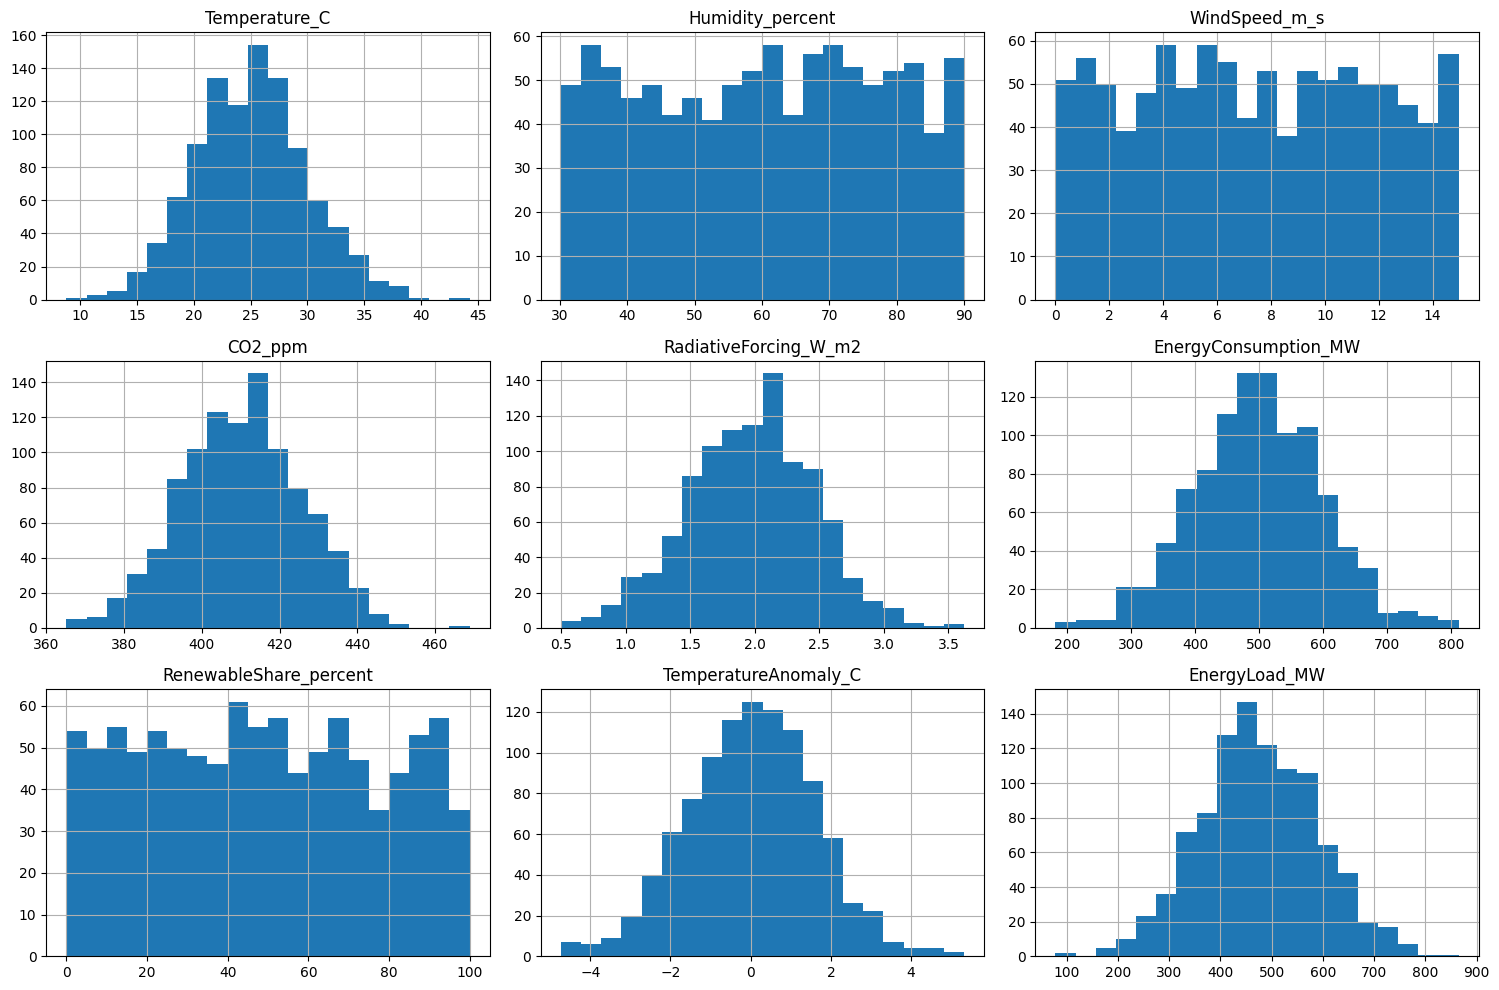

In [10]:
# Plot histograms for all numerical columns
df.hist(figsize=(15, 10), bins=20)

plt.tight_layout()
plt.show()

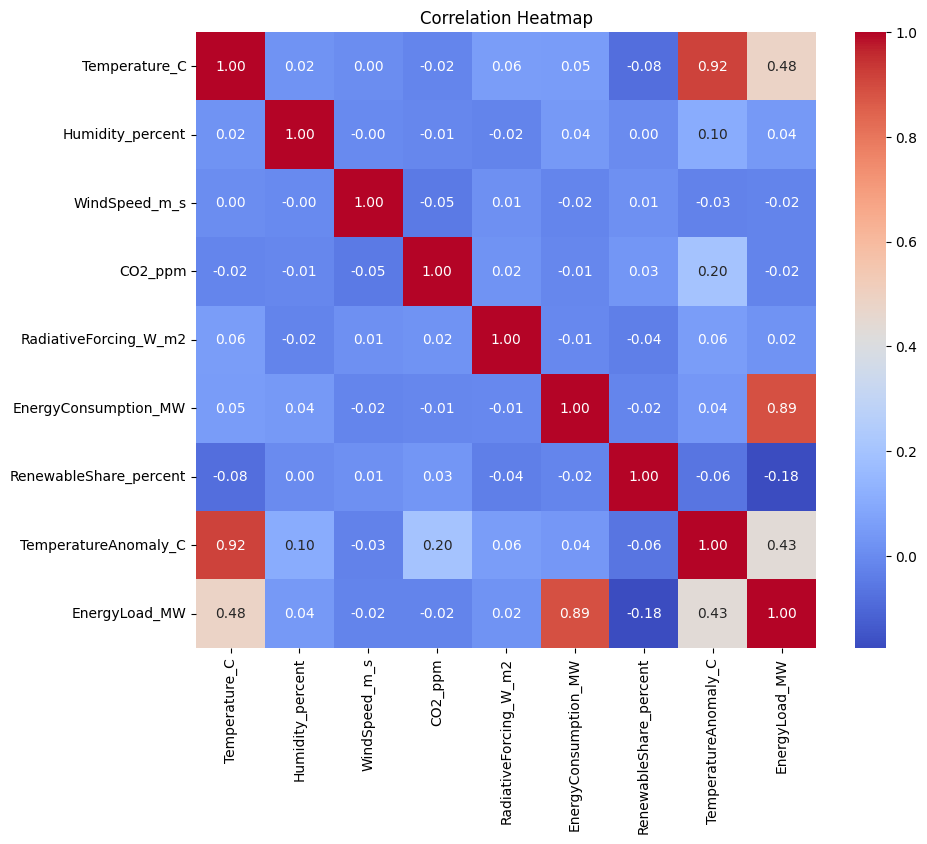

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [12]:
# Select numerical features for clustering
X = df[[
    'Temperature_C',
    'Humidity_percent',
    'WindSpeed_m_s',
    'CO2_ppm',
    'RadiativeForcing_W_m2',
    'EnergyConsumption_MW',
    'RenewableShare_percent',
    'TemperatureAnomaly_C',
    'EnergyLoad_MW'
]]

print(X.head())

   Temperature_C  Humidity_percent  WindSpeed_m_s     CO2_ppm  \
0      27.483571         40.048955       3.286032  400.899496   
1      24.308678         36.274070       0.550820  413.169255   
2      28.238443         68.185815       1.620386  428.001184   
3      32.615149         72.388544       5.082910  402.621463   
4      23.829233         31.895169      12.038785  381.851709   

   RadiativeForcing_W_m2  EnergyConsumption_MW  RenewableShare_percent  \
0               1.513311            472.245574               83.557171   
1               2.503567            629.127384                4.366093   
2               2.168072            542.178007               23.663313   
3               1.886262            631.019191               88.974899   
4               1.588032            478.403948                0.916555   

   TemperatureAnomaly_C  EnergyLoad_MW  
0              1.392456     464.619356  
1             -1.100476     623.984859  
2              1.155829     559.604006  


In [13]:
# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.48775857 -1.16638273 -0.95377374 -0.59790068 -0.93068514 -0.26010414
   1.22493514  0.8612674  -0.08890527]
 [-0.1610219  -1.38467554 -1.58522499  0.19864934  1.09661831  1.31855808
  -1.54822023 -0.70076624  1.29515518]
 [ 0.64201457  0.46070656 -1.3383049   1.16153479  0.40977727  0.44360836
  -0.87245988  0.71300046  0.73601916]
 [ 1.53638248  0.70374059 -0.53894639 -0.48611092 -0.16715998  1.33759485
   1.41465605  1.36575825  1.56211335]
 [-0.25899524 -1.63789726  1.06688774 -1.83447862 -0.77771106 -0.19813398
  -1.66901799 -0.62246922 -0.09647054]]


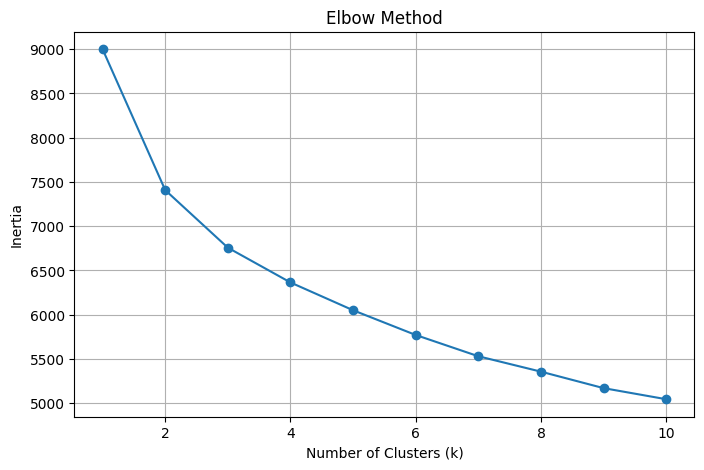

In [14]:
# Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

plt.show()

In [15]:
# Apply K-Means with k=3

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataset
df['Cluster'] = clusters

# Check first few rows
df.head()

,Temperature_C,Humidity_percent,WindSpeed_m_s,CO2_ppm,RadiativeForcing_W_m2,EnergyConsumption_MW,RenewableShare_percent,TemperatureAnomaly_C,EnergyLoad_MW,Cluster
0,27.483571,40.048955,3.286032,400.899496,1.513311,472.245574,83.557171,1.392456,464.619356,1
1,24.308678,36.274070,0.550820,413.169255,2.503567,629.127384,4.366093,-1.100476,623.984859,0
2,28.238443,68.185815,1.620386,428.001184,2.168072,542.178007,23.663313,1.155829,559.604006,2
3,32.615149,72.388544,5.082910,402.621463,1.886262,631.019191,88.974899,2.197600,654.723345,2
4,23.829233,31.895169,12.038785,381.851709,1.588032,478.403948,0.916555,-0.975518,463.748265,0


In [16]:
# Number of records in each cluster
print(df['Cluster'].value_counts().sort_index())

Cluster
0    316
1    327
2    357
Name: count, dtype: int64


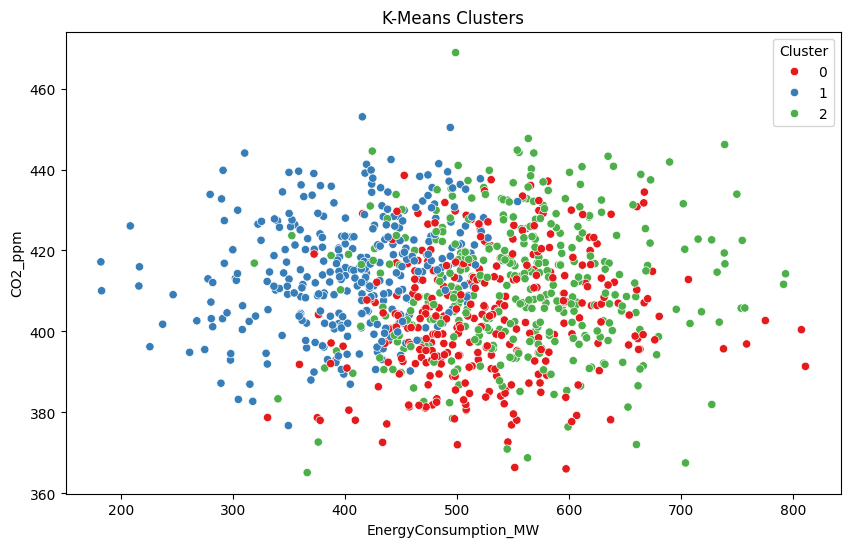

In [18]:
# Visualize clusters using two important features

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='EnergyConsumption_MW',
    y='CO2_ppm',
    hue='Cluster',
    palette='Set1'
)

plt.title('K-Means Clusters')
plt.show()

In [19]:
# View cluster centroids

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

print(centroids)

   Temperature_C  Humidity_percent  WindSpeed_m_s     CO2_ppm  \
0      20.638423         57.209357       7.385756  403.884600   
1      24.743585         60.514961       7.408646  414.850041   
2      29.366292         62.611707       7.453497  411.276856   

   RadiativeForcing_W_m2  EnergyConsumption_MW  RenewableShare_percent  \
0               1.931924            528.002879               46.578363   
1               1.966572            405.751955               57.796366   
2               2.000997            556.201668               41.903001   

   TemperatureAnomaly_C  EnergyLoad_MW  
0             -1.566294     460.885185  
1              0.075344     374.364722  
2              1.367577     579.269563  


In [20]:
# Average values of each feature by cluster

cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)

         Temperature_C  Humidity_percent  WindSpeed_m_s     CO2_ppm  \
Cluster                                                               
0            20.638423         57.209357       7.385756  403.884600   
1            24.743585         60.514961       7.408646  414.850041   
2            29.366292         62.611707       7.453497  411.276856   

         RadiativeForcing_W_m2  EnergyConsumption_MW  RenewableShare_percent  \
Cluster                                                                        
0                     1.931924            528.002879               46.578363   
1                     1.966572            405.751955               57.796366   
2                     2.000997            556.201668               41.903001   

         TemperatureAnomaly_C  EnergyLoad_MW  
Cluster                                       
0                   -1.566294     460.885185  
1                    0.075344     374.364722  
2                    1.367577     579.269563  


In [21]:
# Basic project results

print("Number of Clusters:", kmeans.n_clusters)
print("Dataset Shape:", df.shape)
print("Cluster Distribution:")
print(df['Cluster'].value_counts())

Number of Clusters: 3
Dataset Shape: (1000, 10)
Cluster Distribution:
Cluster
2    357
1    327
0    316
Name: count, dtype: int64
